## Project Introduction
This notebook explores a video game dataset containing detailed game information and user ratings. It focuses on cleaning, preprocessing, and analyzing the data to build a machine learning model that predicts whether a game will be highly rated or not. The project aims to identify key factors that influence game ratings and transform raw data into meaningful insights for predictive modeling.

### Objectives:
- Clean and preprocess the dataset by handling missing values, duplicates, and inconsistent entries
- Define a target variable to classify games as "highly rated" or "not highly rated"
- Identify patterns and relationships between game features and ratings
- Build and evaluate machine learning models for binary classification
- Interpret feature importance to understand what drives high game ratings

### Tools and Libraries:
- Python (Jupyter Notebook)
- Pandas, NumPy for data manipulation
- Matplotlib, Seaborn for visualization
- Scikit-learn for machine learning modeling and evaluation

In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#import data
df = pd.read_csv('../data/raw_data/game_info.csv')
df

,id,slug,name,metacritic,released,tba,updated,website,rating,rating_top,...,developers,genres,publishers,esrb_rating,added_status_yet,added_status_owned,added_status_beaten,added_status_toplay,added_status_dropped,added_status_playing
0,1,dgeneration-hd,D/Generation HD,NaN,2015-10-23,False,2019-09-17T11:58:57,http://dgeneration.net,0.0,0,...,West Coast Software,Adventure||Puzzle,West Coast Software,Everyone 10+,4,88,2,2,0,0
1,10,g-prime,G Prime Into The Rain,NaN,2016-01-06,False,2019-11-06T23:04:19,NaN,0.0,0,...,Soma Games,Simulation||Indie,Immanitas Entertainment||Code-Monkeys,Everyone,2,42,2,0,0,0
2,100,land-sliders,Land Sliders,NaN,2015-09-24,False,2019-10-22T13:56:16,http://prettygreat.com,0.0,0,...,Prettygreat Pty,Adventure||Arcade,Prettygreat Pty,Everyone 10+,0,2,2,0,1,0
3,1000,pixel-gear,Pixel Gear,NaN,2016-10-20,False,2019-08-28T22:16:02,https://www.facebook.com/Geronimo-Interactive-...,0.0,0,...,Oasis Games||Geronimo Interactive,Action||Indie,Geronimo Interactive,Teen,0,1,0,0,0,0
4,10000,gods-and-idols,Gods and Idols,NaN,2016-12-12,False,2019-09-17T13:37:13,http://www.godsandidols.com/,0.0,1,...,Viking Tao,RPG||Strategy||Massively Multiplayer,Viking Tao,NaN,2,79,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474412,99994,holy-or-dead,Holy or Dead,NaN,2017-05-17,False,2019-01-09T12:41:06,NaN,0.0,0,...,Ralidon,NaN,NaN,NaN,0,0,0,0,0,0
474413,99995,airstrike-hd-demo,Airstrike HD Demo,NaN,2016-03-04,False,2019-01-09T12:41:06,NaN,0.0,0,...,Fifth Dimension Company,Action,NaN,NaN,0,0,0,0,0,0
474414,99997,uranias-mirror,Urania's Mirror,NaN,2016-04-25,False,2019-01-09T12:41:06,NaN,0.0,0,...,sneakthief,Adventure,NaN,NaN,0,0,0,0,0,0
474415,99998,simucities,Simucities,NaN,2017-05-26,False,2019-01-09T12:41:06,NaN,0.0,0,...,keypixels,NaN,NaN,NaN,0,0,0,0,0,0


## EDA


In [4]:
#exploring null values
df.isnull().mean().sort_values(ascending=False) * 100

metacritic              99.002354
esrb_rating             88.224705
website                 86.290331
publishers              70.275939
genres                  21.749853
released                 5.100787
developers               1.763428
platforms                0.840189
name                     0.000632
slug                     0.000422
id                       0.000000
added_status_dropped     0.000000
added_status_toplay      0.000000
added_status_beaten      0.000000
added_status_owned       0.000000
added_status_yet         0.000000
suggestions_count        0.000000
reviews_count            0.000000
game_series_count        0.000000
ratings_count            0.000000
achievements_count       0.000000
playtime                 0.000000
rating_top               0.000000
rating                   0.000000
updated                  0.000000
tba                      0.000000
added_status_playing     0.000000
dtype: float64

In [5]:
#exploring the rating of the games
rated_games = df[df['rating'] > 0]

print("Rows:", len(rated_games))

rated_games[['rating']].describe()

Rows: 11994


,rating
count,11994.000000
mean,3.390744
std,0.737789
min,1.000000
25%,2.920000
50%,3.520000
75%,3.990000
max,5.000000


In [6]:
# Data overview
print("Data overview:")
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst few rows:\n{df.head()}")



Data overview:
Shape: (474417, 27)

Data types:
id                        int64
slug                     object
name                     object
metacritic              float64
released                 object
tba                        bool
updated                  object
website                  object
rating                  float64
rating_top                int64
playtime                  int64
achievements_count        int64
ratings_count             int64
suggestions_count         int64
game_series_count         int64
reviews_count             int64
platforms                object
developers               object
genres                   object
publishers               object
esrb_rating              object
added_status_yet          int64
added_status_owned        int64
added_status_beaten       int64
added_status_toplay       int64
added_status_dropped      int64
added_status_playing      int64
dtype: object

First few rows:
      id            slug                   name  metacrit

In [7]:
# Missing values overview
print("Missing values:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)
print(missing_df[missing_df['Missing_Count'] > 0])

Missing values:
             Missing_Count  Percentage
metacritic          469684   99.002354
esrb_rating         418553   88.224705
website             409376   86.290331
publishers          333401   70.275939
genres              103185   21.749853
released             24199    5.100787
developers            8366    1.763428
platforms             3986    0.840189
name                     3    0.000632
slug                     2    0.000422


In [8]:
# Numerical features
print("Numerical features:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe()

Numerical features:


,id,metacritic,rating,rating_top,playtime,achievements_count,ratings_count,suggestions_count,game_series_count,reviews_count,added_status_yet,added_status_owned,added_status_beaten,added_status_toplay,added_status_dropped,added_status_playing
count,474417.000000,4733.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000,474417.000000
mean,266884.000325,73.159307,0.085723,0.098829,0.221662,4.448837,2.142463,92.196848,0.044282,2.162783,0.685030,11.251418,1.361486,0.430767,0.678100,0.149027
std,154567.811630,11.502213,0.545049,0.613023,5.399684,117.671466,36.553606,116.493695,0.771472,36.868160,9.012424,128.531595,28.519725,8.970948,10.484977,3.911149
min,1.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,133664.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,267945.000000,75.000000,0.000000,0.000000,0.000000,0.000000,0.000000,47.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,406010.000000,81.000000,0.000000,0.000000,0.000000,0.000000,0.000000,122.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,525551.000000,99.000000,5.000000,5.000000,1600.000000,12322.000000,4289.000000,1839.000000,28.000000,4334.000000,635.000000,8298.000000,3533.000000,2325.000000,1092.000000,644.000000


In [9]:
# Rating analysis
print("Rating analysis:")
print(f"Rating range: {df['rating'].min()} to {df['rating'].max()}")
print(f"\nRating distribution:")
print(df['rating'].value_counts().sort_index().head(15))


Rating analysis:
Rating range: 0.0 to 5.0

Rating distribution:
rating
0.00    462423
1.00         6
1.11         1
1.13         1
1.17         1
1.18         1
1.21         1
1.22         4
1.24         1
1.25         4
1.29        15
1.30         1
1.31         1
1.33        23
1.35         2
Name: count, dtype: int64


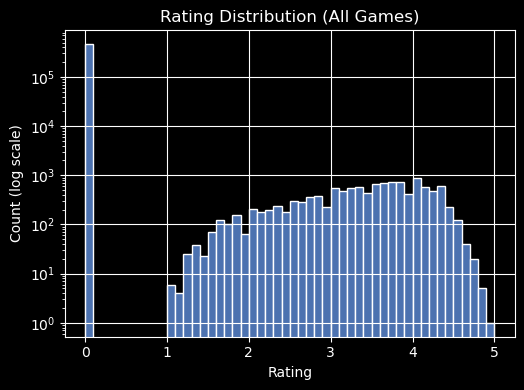

In [10]:
# Visualize rating distribution
plt.style.use('dark_background')

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['rating'].hist(bins=50, edgecolor='white', color='#4C72B0')

plt.yscale('log')  # 👈 key fix

plt.title('Rating Distribution (All Games)', color='white')
plt.xlabel('Rating', color='white')
plt.ylabel('Count (log scale)', color='white')

plt.xticks(color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.show()

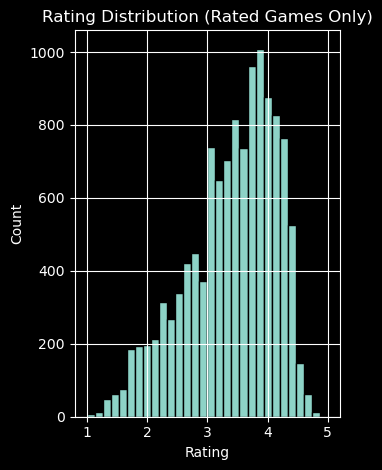

In [11]:
# Rating distribution for rated games only
plt.subplot(1, 2, 2)
rated_games = df[df['rating'] > 0]
rated_games['rating'].hist(bins=30, edgecolor='black')
plt.title('Rating Distribution (Rated Games Only)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [12]:
# Categorical features
print("Categorical features:")
print(f"Unique ESRB ratings: {df['esrb_rating'].unique()}")
print(f"\nESRB distribution:\n{df['esrb_rating'].value_counts()}")



Categorical features:
Unique ESRB ratings: ['Everyone 10+' 'Everyone' 'Teen' nan 'Mature' 'Adults Only'
 'Rating Pending']

ESRB distribution:
esrb_rating
Everyone 10+      36682
Teen              10031
Mature             4859
Everyone           3837
Adults Only         405
Rating Pending       50
Name: count, dtype: int64


In [13]:
# Key metrics distribution
key_metrics = ['metacritic', 'playtime', 'ratings_count', 'achievements_count', 'reviews_count']
print(df[key_metrics].describe())

        metacritic       playtime  ratings_count  achievements_count  \
count  4733.000000  474417.000000  474417.000000       474417.000000   
mean     73.159307       0.221662       2.142463            4.448837   
std      11.502213       5.399684      36.553606          117.671466   
min      15.000000       0.000000       0.000000            0.000000   
25%      67.000000       0.000000       0.000000            0.000000   
50%      75.000000       0.000000       0.000000            0.000000   
75%      81.000000       0.000000       0.000000            0.000000   
max      99.000000    1600.000000    4289.000000        12322.000000   

       reviews_count  
count  474417.000000  
mean        2.162783  
std        36.868160  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max      4334.000000  


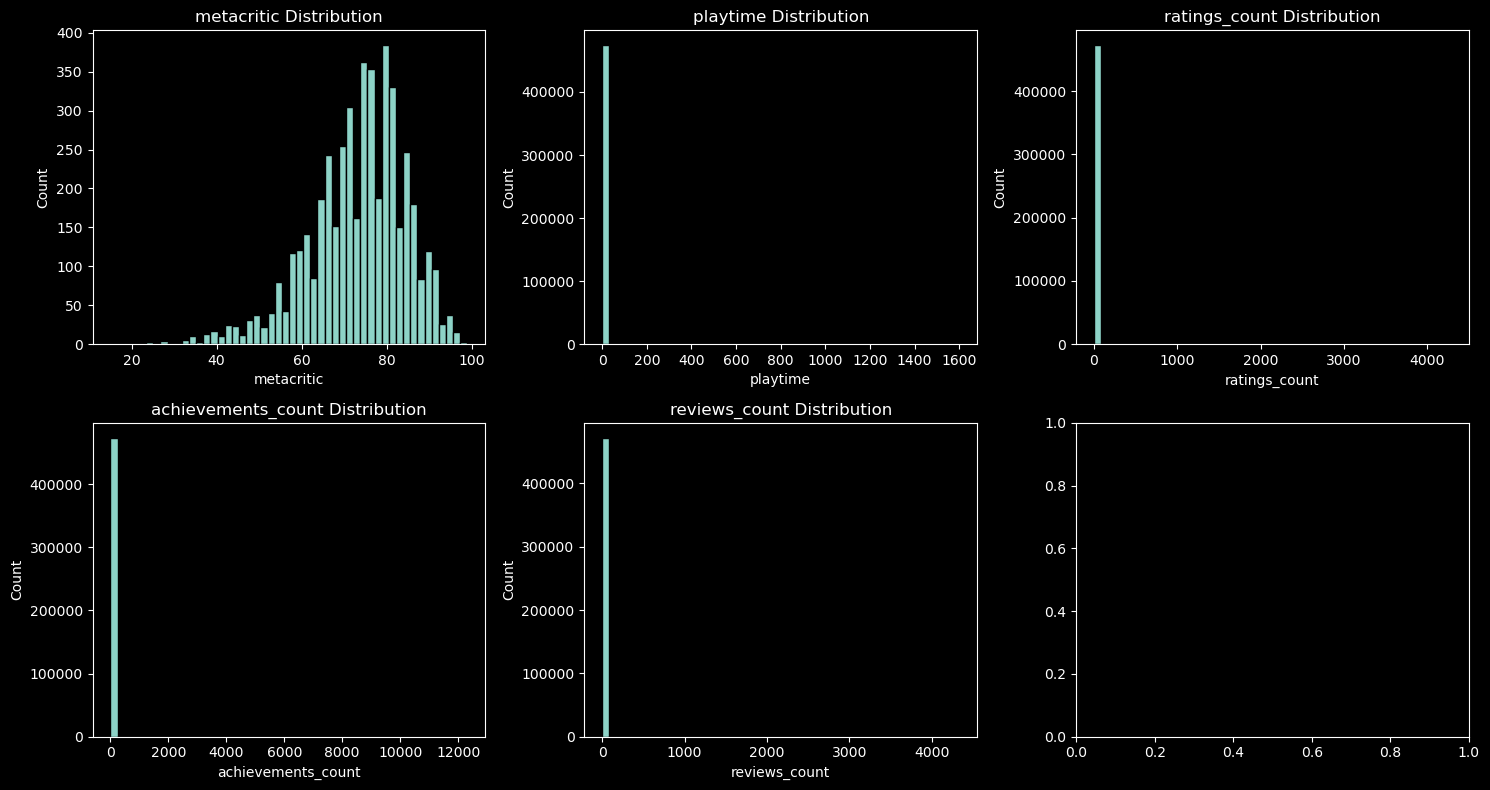

In [15]:
# Visualize key metrics
fig, axes = plt.subplots(2,3, figsize=(15,8))
axes = axes.flatten()

for idx, col in enumerate(key_metrics):
    axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black')
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [16]:
# Correlation analysis
correlation = df[key_metrics + ['rating']].corr()
print(correlation['rating'].sort_values(ascending=False))

rating                1.000000
metacritic            0.442042
reviews_count         0.381308
ratings_count         0.381224
playtime              0.102665
achievements_count    0.046513
Name: rating, dtype: float64


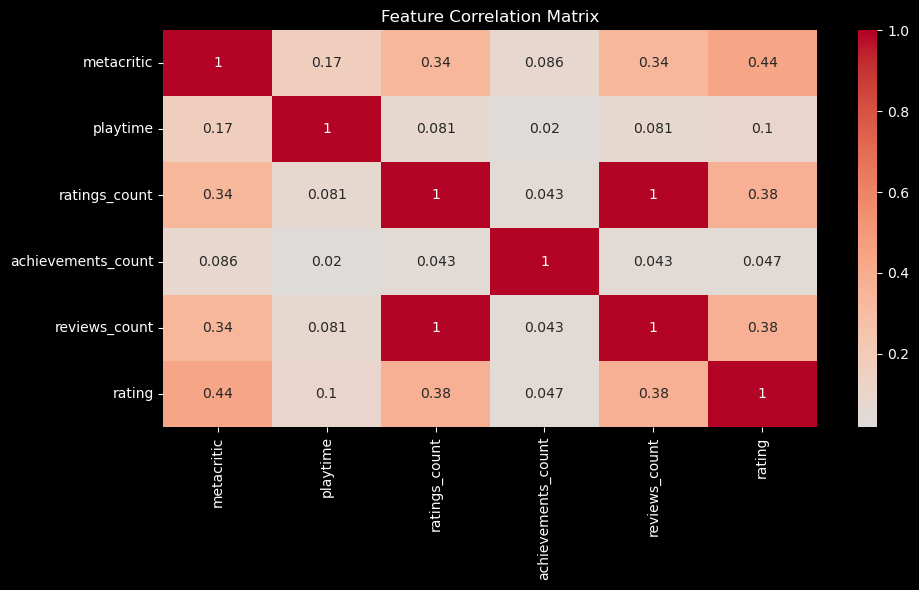

In [17]:
# visualize correlation
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [18]:
# Checking dupplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [19]:
# platform & fenre analysis
print(f"Sample platforms: {df['platforms'].head(3).values}")
print(f"Sample genres: {df['genres'].head(3).values}")

Sample platforms: ['PC||macOS||Xbox One||PlayStation 4||Nintendo Switch'
 'macOS||PC||Xbox One' 'iOS']
Sample genres: ['Adventure||Puzzle' 'Simulation||Indie' 'Adventure||Arcade']
